<a href="https://colab.research.google.com/github/nihlahh/praktikum-pengolahan-citra/blob/main/Jobsheet05_nihlah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jarak Euclidean (Patch1 vs Patch2): 24.7650
Jarak Euclidean (Patch1 vs Patch3): 5.0000
Jarak Manhattan (Patch1 vs Patch2): 936.4392
Jarak Manhattan (Patch1 vs Patch3): 250.0000


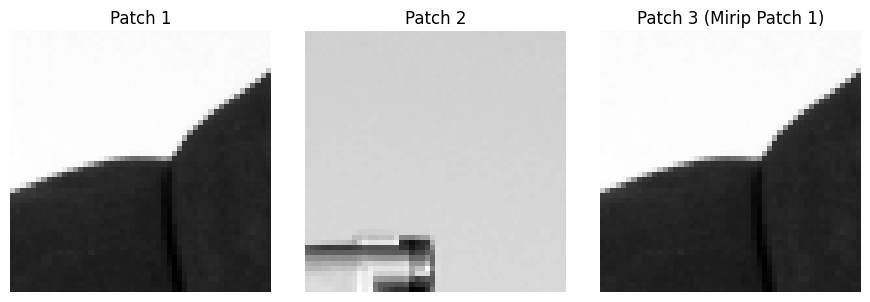

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Ambil citra dan buat patch
image = img_as_float(data.camera())

patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda

# Patch 3 = patch1 + sedikit noise
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)  # Pastikan tetap di range [0,1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil
print(f"Jarak Euclidean (Patch1 vs Patch2): {dist_l2_12:.4f}")
print(f"Jarak Euclidean (Patch1 vs Patch3): {dist_l2_13:.4f}")
print(f"Jarak Manhattan (Patch1 vs Patch2): {dist_l1_12:.4f}")
print(f"Jarak Manhattan (Patch1 vs Patch3): {dist_l1_13:.4f}")

# 6. Visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Cosine Similarity (Image1 vs Image2 / Astronaut vs Coffee): 0.8156
Cosine Similarity (Image1 vs Image3 / Astronaut vs Astronaut): 1.0000
Cosine Similarity (Image1 vs Image4 / Astronaut vs Downsampled): 1.0000


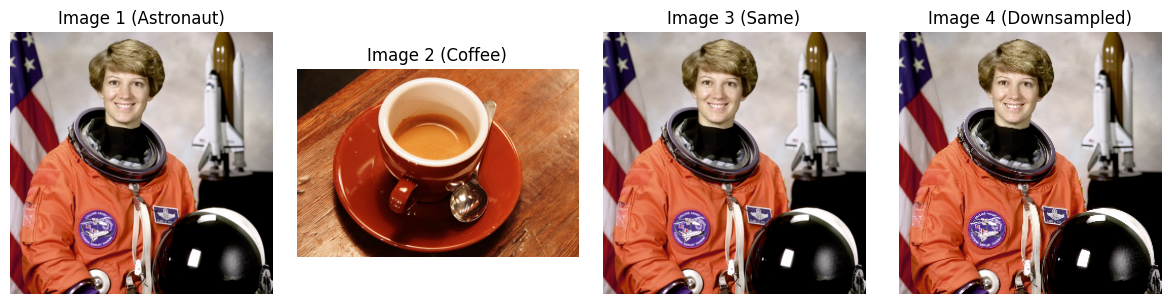

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined


# 1. Muat citra
try:
    image1 = data.astronaut()
    image2 = data.coffee()        # Citra berbeda
    image3 = data.astronaut()     # Citra sama
    image4 = image1[::2, ::2, :]  # Downsample dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Menggunakan citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]


# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)


# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)


# 4. Tampilkan hasil
print(f"Cosine Similarity (Image1 vs Image2 / Astronaut vs Coffee): {sim_12:.4f}")
print(f"Cosine Similarity (Image1 vs Image3 / Astronaut vs Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity (Image1 vs Image4 / Astronaut vs Downsampled): {sim_14:.4f}")


# 5. Visualisasi citra
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1 (Astronaut)')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2 (Coffee)')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2954
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


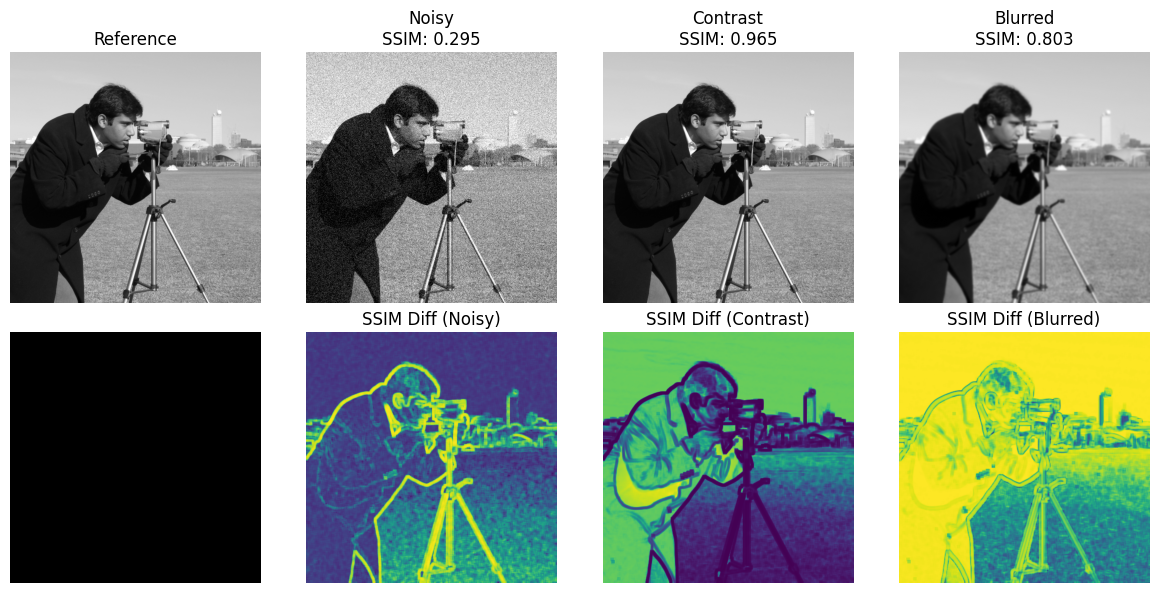

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat variasi citra
image_same = image_ref.copy()  # Sama persis
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)  # Noise
image_contrast = np.clip(image_ref * 0.8, 0, 1)  # Kontras turun
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # Blur

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Print hasil
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris atas (citra)
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Baris bawah (difference map)
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Diff (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Diff (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Diff (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

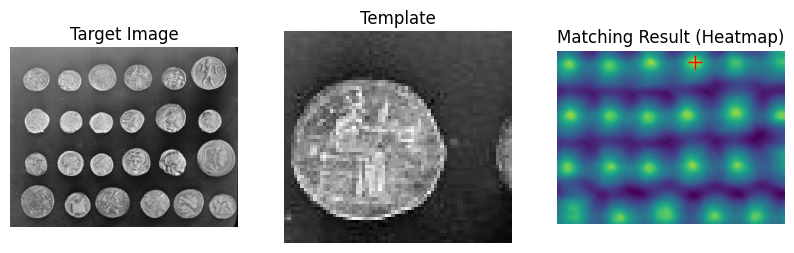

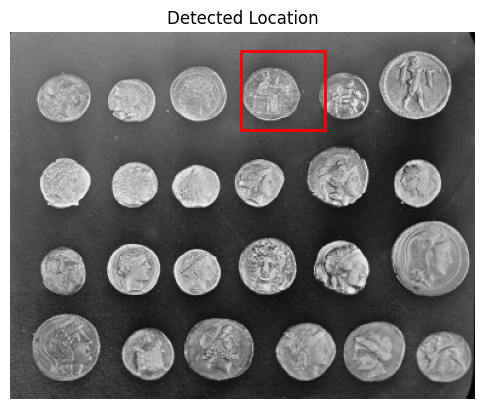

Template ditemukan di koordinat (x, y): (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from matplotlib.patches import Rectangle

# 1. Muat citra dan template
image = data.coins()
template = image[15:80, 190:260]

# 2. Template matching (Normalized Cross-Correlation)
result = match_template(image, template)

# 3. Cari lokasi dengan skor tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # (x, y)

# Ukuran template
h, w = template.shape

# 4. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# Citra asli
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=10)

# 5. Tampilkan bounding box di citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Detected Location')
ax_main.axis('off')

# Rectangle (bounding box)
rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
ax_main.add_patch(rect)

plt.show()

# 6. Output koordinat
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin kecil distance = semakin mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


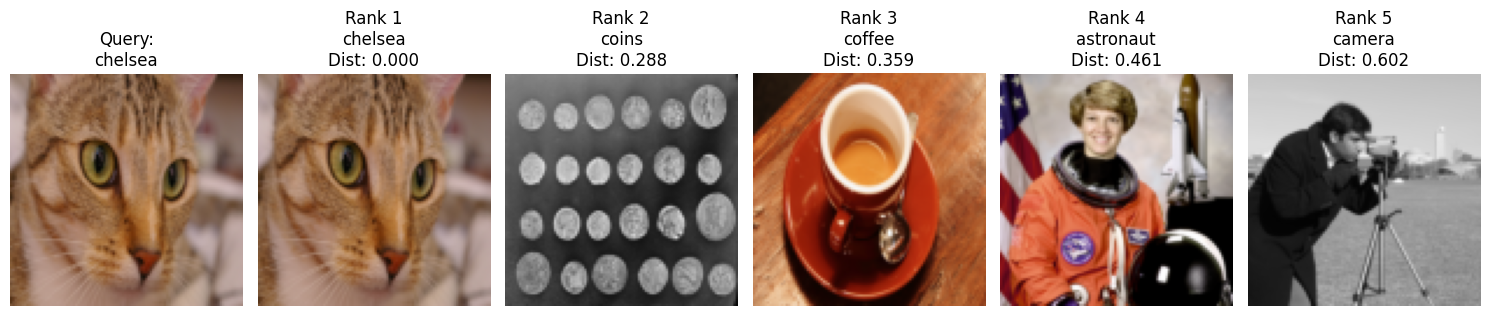

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    # Konversi ke uint8 jika float
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined


# 1. Database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()

        # Jika grayscale → ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)

        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))

        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")


# 2. Query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]


# 3. Hitung jarak (Cosine Distance)
distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)


# 4. Sorting hasil
sorted_indices = np.argsort(distances)


# 5. Visualisasi
num_results = len(database_images)
fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))

# Query
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin kecil distance = semakin mirip):")

# Hasil ranking
for i, idx in enumerate(sorted_indices):
    ax = axes[i + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')

    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

Memproses database (Mean RGB)...
- astronaut diproses
- camera diproses
- coffee diproses
- coins diproses
- chelsea diproses

Hasil Retrieval (Mean RGB - Euclidean):
Rank 1: chelsea (Distance: 0.0000)
Rank 2: astronaut (Distance: 0.0501)
Rank 3: coffee (Distance: 0.1765)
Rank 4: camera (Distance: 0.1938)
Rank 5: coins (Distance: 0.2110)


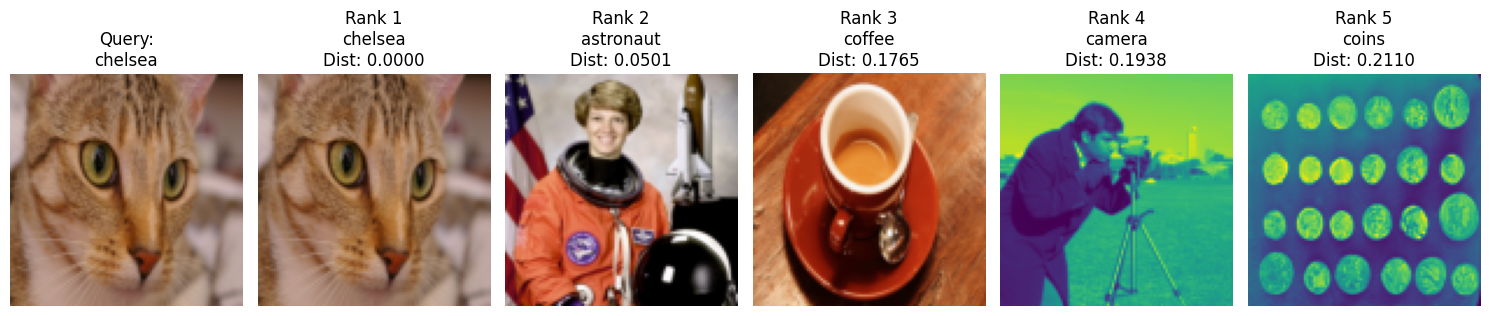

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

# ==============================
# 1. Fungsi fitur Mean RGB
# ==============================
def calculate_mean_rgb(image):
    # Jika grayscale → ubah ke RGB
    if image.ndim == 2:
        image = color.gray2rgb(image)

    # Hitung rata-rata tiap channel
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])

    return np.array([mean_r, mean_g, mean_b])


# ==============================
# 2. Siapkan database citra
# ==============================
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Memproses database (Mean RGB)...")

for name in image_db_names:
    try:
        img = getattr(data, name)()

        # Resize biar konsisten
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)

        database_images.append(img_resized)
        database_features.append(calculate_mean_rgb(img_resized))

        print(f"- {name} diproses")
    except Exception as e:
        print(f"Error: {name} → {e}")


# ==============================
# 3. Pilih query
# ==============================
query_name = "chelsea"
query_index = image_db_names.index(query_name)

query_image = database_images[query_index]
query_feature = database_features[query_index]


# ==============================
# 4. Hitung jarak Euclidean
# ==============================
distances = []

for feat in database_features:
    dist = distance.euclidean(query_feature, feat)
    distances.append(dist)


# ==============================
# 5. Ranking hasil
# ==============================
sorted_indices = np.argsort(distances)


# ==============================
# 6. Visualisasi hasil
# ==============================
num_results = len(database_images)
fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))

# Query
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_name}")
axes[0].axis('off')

print("\nHasil Retrieval (Mean RGB - Euclidean):")

# Hasil ranking
for i, idx in enumerate(sorted_indices):
    ax = axes[i + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.4f}")
    ax.axis('off')

    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances[idx]:.4f})")

plt.tight_layout()
plt.show()

=== HASIL TEMPLATE MATCHING ===
Template Asli     : 1.0000
Template Rotasi   : 0.6059
Template Skala    : 0.6072


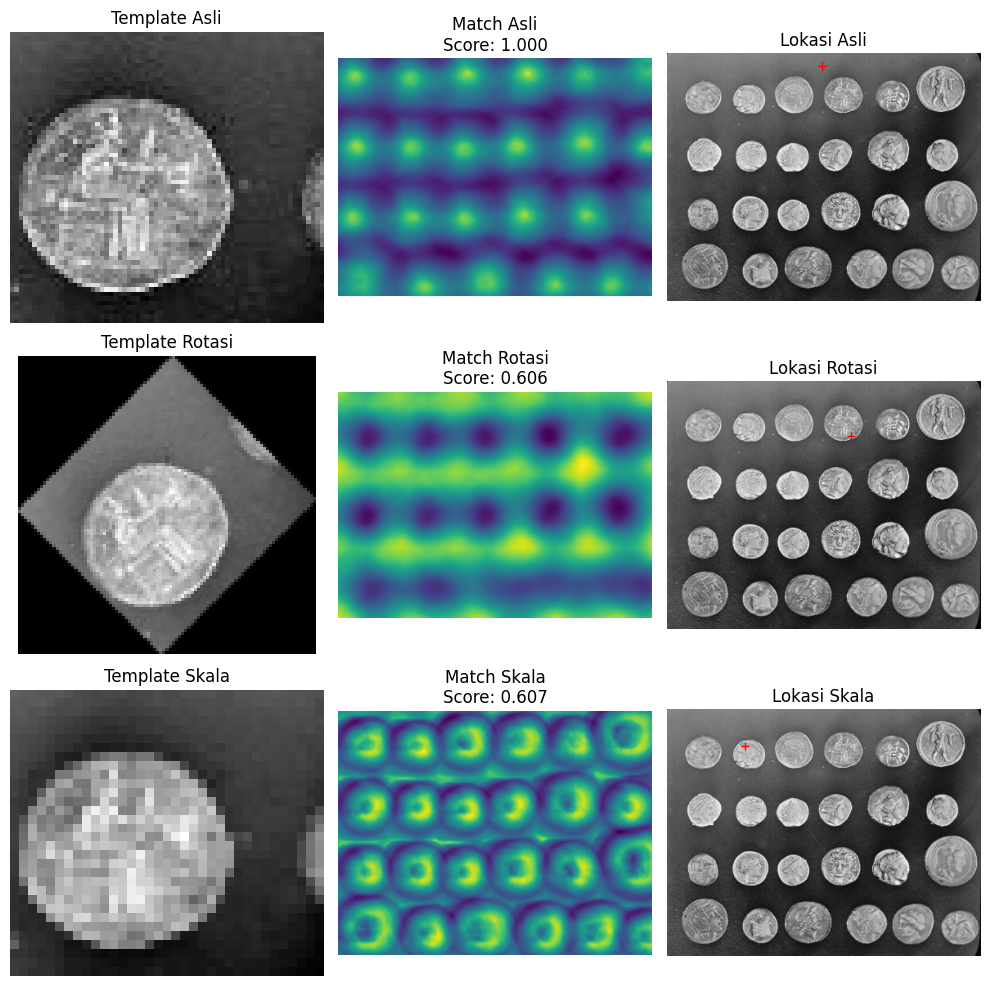

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

# 1. Load image dan template
image = data.coins()
template = image[15:80, 190:260]

# 2. Buat variasi template
template_rotated = transform.rotate(template, angle=45, resize=True)
template_scaled = transform.rescale(template, scale=0.5, anti_aliasing=True)

# 3. Fungsi untuk cari nilai max similarity
def get_max_match(img, temp):
    result = match_template(img, temp)
    return np.max(result), result

# 4. Hitung similarity
score_original, res_original = get_max_match(image, template)
score_rotated, res_rotated = get_max_match(image, template_rotated)
score_scaled, res_scaled = get_max_match(image, template_scaled)

# 5. Print hasil
print("=== HASIL TEMPLATE MATCHING ===")
print(f"Template Asli     : {score_original:.4f}")
print(f"Template Rotasi   : {score_rotated:.4f}")
print(f"Template Skala    : {score_scaled:.4f}")

# 6. Visualisasi
fig, ax = plt.subplots(3, 3, figsize=(10, 10))

# Template asli
ax[0,0].imshow(template, cmap='gray')
ax[0,0].set_title("Template Asli")
ax[0,0].axis('off')

ax[0,1].imshow(res_original, cmap='viridis')
ax[0,1].set_title(f"Match Asli\nScore: {score_original:.3f}")
ax[0,1].axis('off')

# Tandai lokasi terbaik
y, x = np.unravel_index(np.argmax(res_original), res_original.shape)
ax[0,2].imshow(image, cmap='gray')
ax[0,2].plot(x, y, 'r+')
ax[0,2].set_title("Lokasi Asli")
ax[0,2].axis('off')

# Template rotasi
ax[1,0].imshow(template_rotated, cmap='gray')
ax[1,0].set_title("Template Rotasi")
ax[1,0].axis('off')

ax[1,1].imshow(res_rotated, cmap='viridis')
ax[1,1].set_title(f"Match Rotasi\nScore: {score_rotated:.3f}")
ax[1,1].axis('off')

# Lokasi rotasi
y, x = np.unravel_index(np.argmax(res_rotated), res_rotated.shape)
ax[1,2].imshow(image, cmap='gray')
ax[1,2].plot(x, y, 'r+')
ax[1,2].set_title("Lokasi Rotasi")
ax[1,2].axis('off')

# Template skala
ax[2,0].imshow(template_scaled, cmap='gray')
ax[2,0].set_title("Template Skala")
ax[2,0].axis('off')

ax[2,1].imshow(res_scaled, cmap='viridis')
ax[2,1].set_title(f"Match Skala\nScore: {score_scaled:.3f}")
ax[2,1].axis('off')

# Lokasi skala
y, x = np.unravel_index(np.argmax(res_scaled), res_scaled.shape)
ax[2,2].imshow(image, cmap='gray')
ax[2,2].plot(x, y, 'r+')
ax[2,2].set_title("Lokasi Skala")
ax[2,2].axis('off')

plt.tight_layout()
plt.show()